# MIMO MTS test on ZCU216
---

The following results were captured when looping back all 16 DACs to 16 ADCs through equal-length cables.

### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
# clear cached hwh, per PYNQ issue 1409
from pynq import PL
PL.reset()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

from pynq import Clocks
from mimo_mts import MimoMtsOverlay

%load_ext autoreload
%autoreload 2

In [4]:
ol = MimoMtsOverlay(
    "mimo_mts.bit",
    board = 'ZCU216',
    lmk_tcs='designs/CLK104/LMK04828_499.64MHz_CLKin0_499.64MHz.tcs',
    lmxadc_tcs='designs/CLK104/LMX2594_2000MHz.tcs',
    lmxdac_tcs='designs/CLK104/LMX2594_4000MHz.tcs')

print(f'Overlay loaded :{ol.is_loaded()}')

Overlay loaded :True


In [5]:
print(f'DSPCLK Freq: {ol.dspclk_freq_hz / 1e6:10.3f} MHz')

DSPCLK Freq:    249.821 MHz


In [6]:
for i in range(4):
    print(f"DAC Tile {i} Latency: {ol.rfdc.mts_dac_config.Latency[i]:3d}, "
          f"Offset: {ol.rfdc.mts_dac_config.Offset[i]}\n"
          f"ADC Tile {i} Latency: {ol.rfdc.mts_adc_config.Latency[i]:3d}, "
          f"Offset: {ol.rfdc.mts_adc_config.Offset[i]}")

DAC Tile 0 Latency: 136, Offset: 16
ADC Tile 0 Latency: 104, Offset: 8
DAC Tile 1 Latency: 136, Offset: 16
ADC Tile 1 Latency: 104, Offset: 8
DAC Tile 2 Latency: 136, Offset: 16
ADC Tile 2 Latency: 104, Offset: 8
DAC Tile 3 Latency: 136, Offset: 16
ADC Tile 3 Latency: 104, Offset: 8


In [7]:
print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz


# Configure trigger

internal, 1Hz

In [8]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 0
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096

In [9]:
from mimo_mts.utils.plot import plot_adc_wfm, plot_adc_psd, plot_complex_wfm_stack

fs = ol.board.adc_sampling_rate

# Generate Waveforms for Loopback
 This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
### Prepare the DAC Memory
The cell below generates examples waveforms and has customizable paramters.  For example, one can adjust the center frequency, Fc, and re-generate a sinewave.

In [10]:
Fc = fs / 16 / 2 # 125 MHz
t = np.arange(ol.dac_player.size) / fs
amp =  (1 << 14) - 1
DAC_sinewave = amp * np.sin(2 * np.pi * Fc * t)

In [11]:
dac_i = np.int16(DAC_sinewave)[::2]
dac_q = np.zeros_like(dac_i)
ol.write_dac_iq_buf(dac_i, dac_q)

## Capture DAC Waveform to Internal Memory

The DAC waveform is saved to an internal memory for verification purposes.


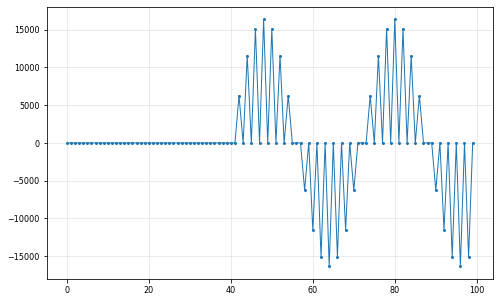

In [12]:
plt.plot(ol.dac_capture[600:700], marker='o', linewidth=1, markersize=2);

In [13]:
ol.set_adc_mixer_dco(freq_mhz=0, phase=0)
darray_i, darray_q = ol.capture_adc_iq_buf();

In [14]:
start = 1210 // 2 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9} ns')

RF loop back latency: 302.5 ns


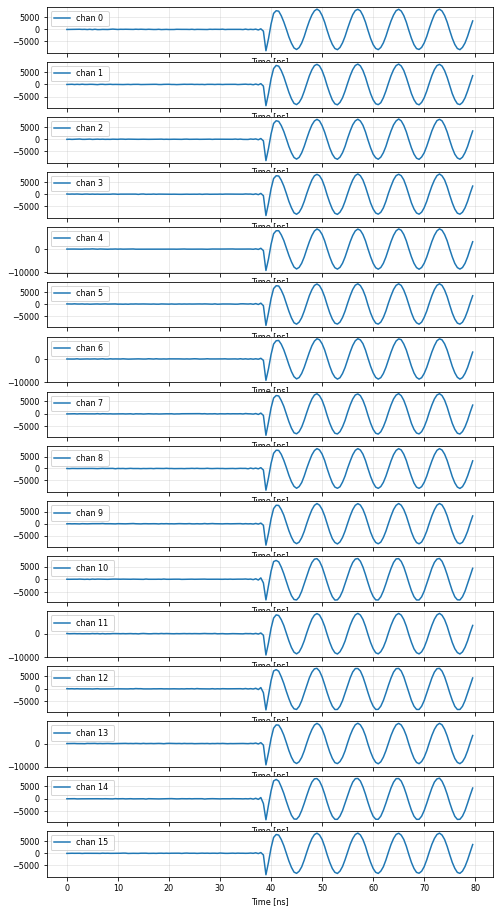

In [15]:
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

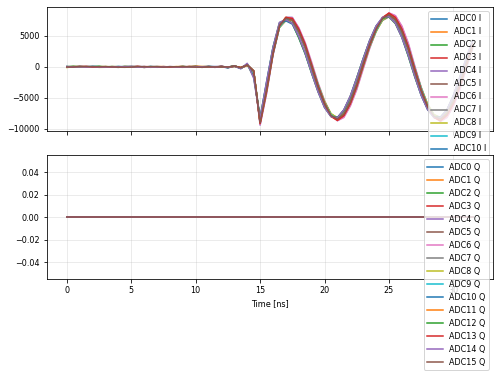

In [16]:
ol.set_adc_mixer_dco(phase=0)
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)

### Change mixer phase to 90 deg and check I/Q waveforms

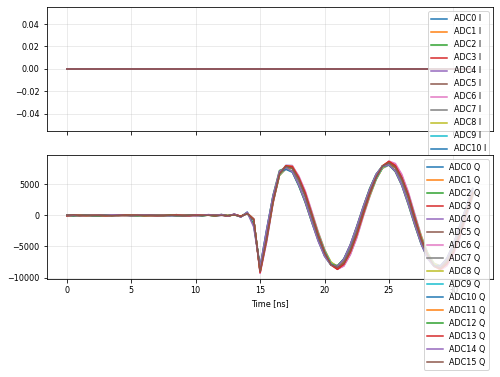

In [17]:
ol.set_adc_mixer_dco(phase=90)
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)


### Verify Alignment Stability

In [18]:
n_samples = 1024
for i in range(3):
    ol.capture_adc_iq_buf(darray_i, darray_q);
    x = darray_q[0, start:start+n_samples].astype(np.float32)  # adc0 Q
    y = darray_q[3, start:start+n_samples].astype(np.float32)  # adc3 Q
    x_corr = np.correlate(x, y, mode='full')
    lags = np.arange(-n_samples+1, n_samples)
    delay = lags[np.argmax(x_corr)]
    print(f'Iteration {i} : Cross-correlation delay = {delay} samples')
    assert delay == 0, 'Cross-correlation delay is not zero'

Iteration 0 : Cross-correlation delay = 0 samples
Iteration 1 : Cross-correlation delay = 0 samples
Iteration 2 : Cross-correlation delay = 0 samples


### Set DAC baseband waveform as DC, reset mixer

In [19]:
n_samples = ol.dac_player.size
ol.dac_player[:] = np.ones(n_samples, dtype=np.int16) * 16384
ol.set_dac_mixer_dco(0)
ol.set_adc_mixer_dco(0)

### Change DAC mixer setting with NCO to 125 MHz

In [20]:
ol.set_dac_mixer_dco(125)

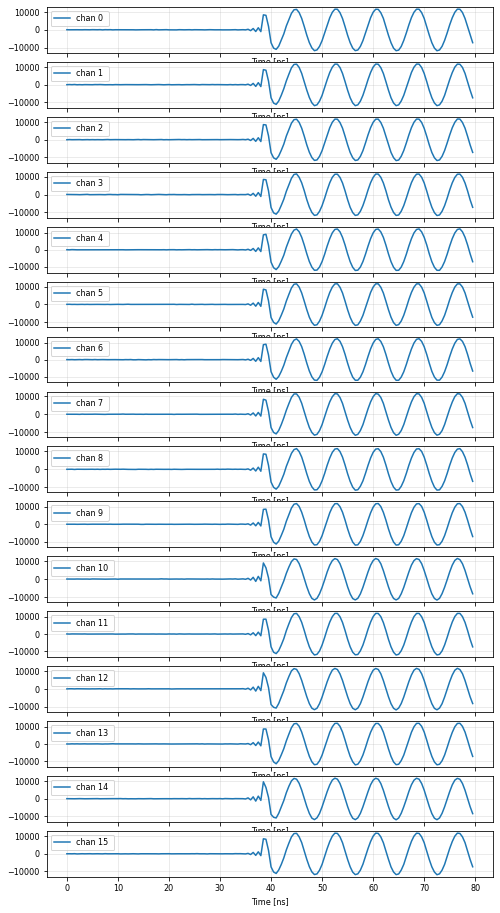

In [21]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)